In [1]:
import pandas as pd

In [3]:
import seaborn as sn

In [34]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
k=pd.read_csv('Reliance.csv')

In [7]:
k

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0
...,...,...,...,...,...,...,...
1228,2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0
1229,2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0
1230,2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0
1231,2020-11-13,1982.000000,2036.650024,1981.750000,1996.400024,1996.400024,20946864.0


In [8]:
k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1233 non-null   object 
 1   Open       1232 non-null   float64
 2   High       1232 non-null   float64
 3   Low        1232 non-null   float64
 4   Close      1232 non-null   float64
 5   Adj Close  1232 non-null   float64
 6   Volume     1232 non-null   float64
dtypes: float64(6), object(1)
memory usage: 67.6+ KB


In [9]:
k.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1.232000e+03
mean,1036.035414,1048.479285,1023.015573,1035.164502,1024.471417,9.981743e+06
std,463.719976,469.906022,455.946191,462.301697,466.231636,7.603435e+06
min,459.000000,465.649994,444.049988,453.274994,434.061554,1.283997e+06
25%,551.925003,561.393768,546.000000,553.049988,540.720703,5.555522e+06
50%,959.099976,972.474976,946.675018,960.949982,946.843903,7.560520e+06
75%,1309.024963,1321.649963,1292.274963,1308.337494,1298.972321,1.140781e+07
max,2325.000000,2369.350098,2310.550049,2324.550049,2324.550049,6.523004e+07


In [12]:
k.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume       float64
dtype: object

In [13]:
k['Date']=pd.to_datetime(k['Date'])

In [15]:
k.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

In [17]:
k.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [19]:
k=k.dropna()

In [20]:
k.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [23]:
k.set_index(k['Date'])

,Date,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2015-11-18,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
2015-11-19,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2015-11-20,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
2015-11-23,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
2015-11-24,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0
...,...,...,...,...,...,...,...
2020-11-10,2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0
2020-11-11,2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0
2020-11-12,2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0


In [25]:
data=k['Close']

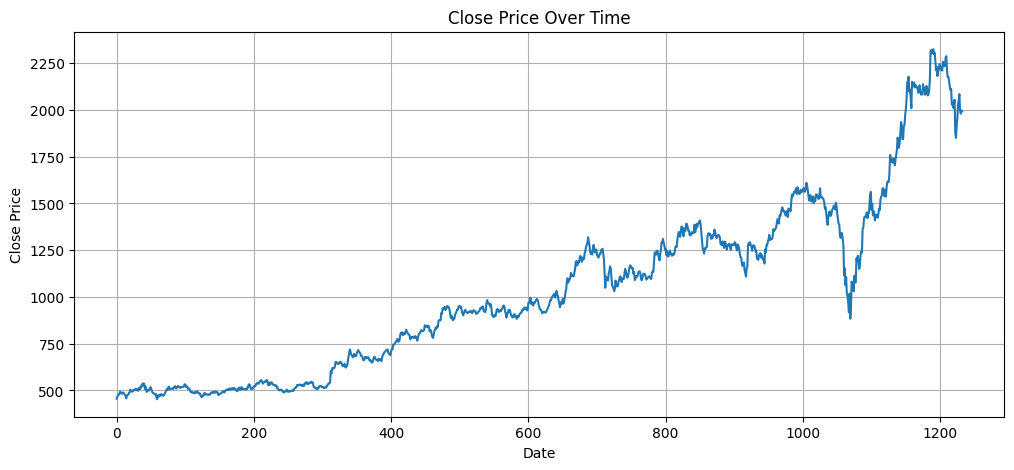

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(data)
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid()
plt.show()

In [27]:
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

In [28]:
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import warnings

In [29]:
warnings.filterwarnings('ignore')

In [30]:
ar = AutoReg(train, lags=5)
ar_fit = ar.fit()

In [31]:
predictions = ar_fit.predict(start=len(train), end=len(train)
+len(test)-1, dynamic=False)

In [32]:
mse = mean_squared_error(test, predictions)
print(f'Mean Squared Error: {mse:.2f}')

Mean Squared Error: 90622.45


In [35]:
np.sqrt(mse)

np.float64(301.035626624822)

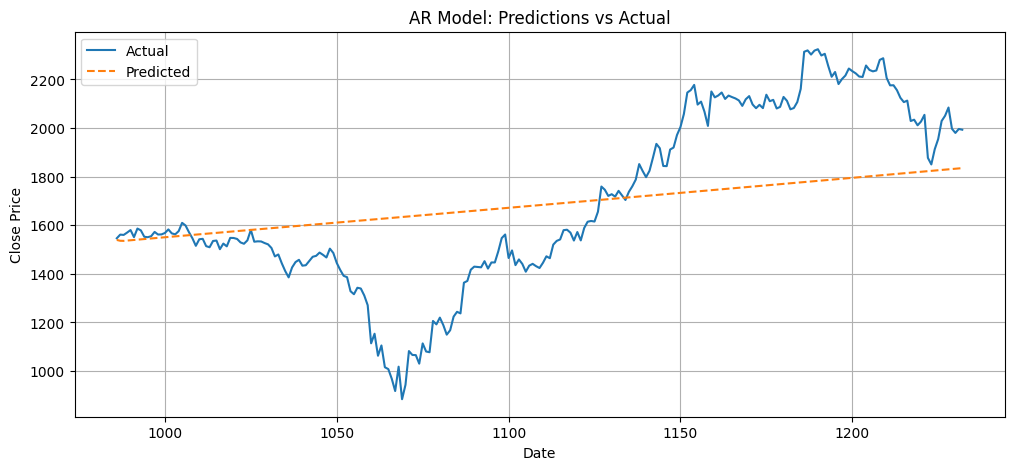

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted', linestyle='--')
plt.title('AR Model: Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

In [38]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(data)
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
data_diff = data.diff().dropna()

ADF Statistic: -0.29369400111453287
p-value: 0.9263927141389081


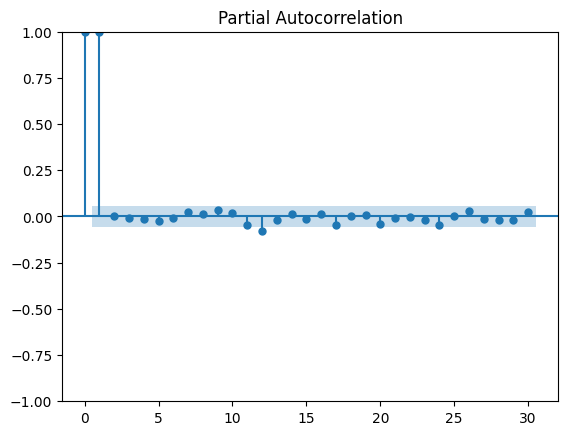

In [39]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(data, lags=30)
plt.show()

In [43]:
for lag in range(1, 21):
    ar = AutoReg(train, lags=lag).fit()
    print(f'Lag: {lag}, AIC: {ar.aic:.2f}, BIC: {ar.bic:.2f}')

Lag: 1, AIC: 8164.97, BIC: 8179.64
Lag: 2, AIC: 8154.83, BIC: 8174.39
Lag: 3, AIC: 8144.80, BIC: 8169.24
Lag: 4, AIC: 8137.91, BIC: 8167.24
Lag: 5, AIC: 8130.19, BIC: 8164.40
Lag: 6, AIC: 8118.15, BIC: 8157.25
Lag: 7, AIC: 8111.76, BIC: 8155.72
Lag: 8, AIC: 8106.30, BIC: 8155.14
Lag: 9, AIC: 8099.61, BIC: 8153.33
Lag: 10, AIC: 8093.86, BIC: 8152.45
Lag: 11, AIC: 8088.51, BIC: 8151.97
Lag: 12, AIC: 8082.29, BIC: 8150.62
Lag: 13, AIC: 8076.56, BIC: 8149.75
Lag: 14, AIC: 8070.71, BIC: 8148.76
Lag: 15, AIC: 8064.60, BIC: 8147.51
Lag: 16, AIC: 8058.11, BIC: 8145.88
Lag: 17, AIC: 8047.46, BIC: 8140.09
Lag: 18, AIC: 8032.97, BIC: 8130.45
Lag: 19, AIC: 8026.91, BIC: 8129.25
Lag: 20, AIC: 8019.90, BIC: 8127.09


In [45]:
best_lag = 20
ar = AutoReg(train, lags=best_lag)
ar_fit = ar.fit()
predictions = ar_fit.predict(start=len(train), end=len(train)
+len(test)-1, dynamic=False)
len(predictions)

247

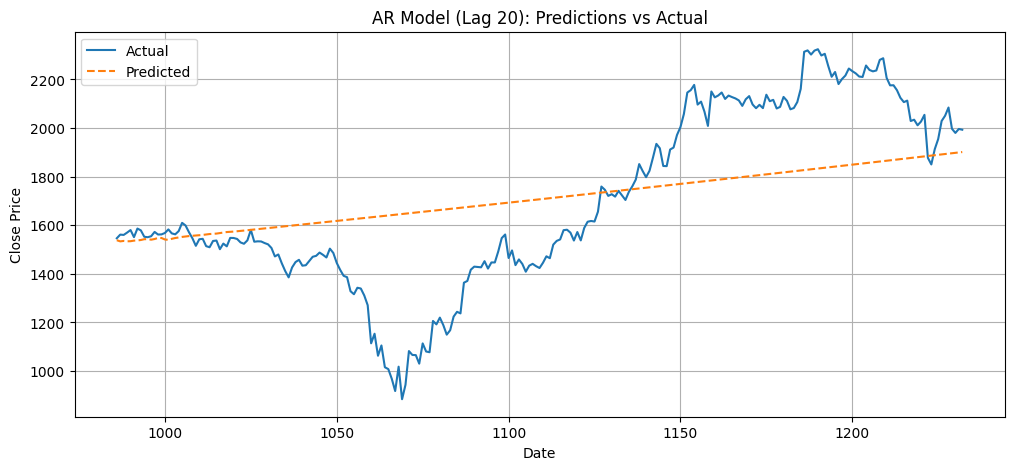

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Predicted', linestyle='--')
plt.title(f'AR Model (Lag {best_lag}): Predictions vs Actual')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

In [47]:
print(predictions)

985     1538.506739
986     1533.744061
987     1535.541994
988     1533.981643
989     1534.405652
           ...     
1227    1894.800356
1228    1896.433178
1229    1898.066896
1230    1899.701511
1231    1901.337024
Length: 247, dtype: float64


In [48]:
future_steps = 30
future_predictions = ar_fit.predict(start=len(train) + len(test),
end=len(train) + len(test) +
future_steps - 1,
dynamic=False)
print("Future Predicted Close Prices:")
print(future_predictions)

Future Predicted Close Prices:
1232    1902.973435
1233    1904.610744
1234    1906.248953
1235    1907.888061
1236    1909.528069
1237    1911.168977
1238    1912.810787
1239    1914.453497
1240    1916.097110
1241    1917.741626
1242    1919.387044
1243    1921.033366
1244    1922.680591
1245    1924.328722
1246    1925.977757
1247    1927.627697
1248    1929.278544
1249    1930.930297
1250    1932.582957
1251    1934.236524
1252    1935.890999
1253    1937.546383
1254    1939.202676
1255    1940.859878
1256    1942.517990
1257    1944.177013
1258    1945.836946
1259    1947.497791
1260    1949.159548
1261    1950.822217
dtype: float64
